In [49]:
from langchain_community.document_loaders import TextLoader,WebBaseLoader,PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_groq import ChatGroq
from langchain_core.output_parsers import StrOutputParser
from dotenv import load_dotenv
import os
from langchain_groq import ChatGroq
from pydantic import BaseModel,Field
from typing import Literal,List,TypedDict,Annotated
from dataclasses import dataclass
from langgraph.graph import StateGraph,START,END
from IPython.display import display,Image
from langchain_core.prompts import PromptTemplate,ChatPromptTemplate
import warnings
warnings.filterwarnings("ignore")
load_dotenv()

llm=ChatGroq(model="llama-3.1-8b-instant",temperature=0.1)


In [50]:
class Worker(BaseModel):
    evaluation:Literal["satisfy","notsatisfy"]

llm_evaluator=llm.with_structured_output(Worker)



class State(TypedDict):
    query:str
    chunks:List[str]
    evaluation:str
    query_rewriter:str
    answer:str
    

document=PyPDFLoader("transformer.pdf").load()

splitter=RecursiveCharacterTextSplitter(chunk_size=550,chunk_overlap=50)

docs=splitter.split_documents(document)

embeddings=HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

vectordb=FAISS.from_documents(docs,embeddings)

retriever_obj=vectordb.as_retriever(search_type="mmr",search_kwargs={"k":5,"fetch_k":15,"lambda_mult":0.25})

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 526.51it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [51]:
def retriever(state:State):
    
    result=retriever_obj.invoke(state["query"])
    chunks=[chunk.page_content for chunk in result]

    return {"chunks":chunks}

def evaluator(state:State):
    prompt= f"""You are an evaluator.
Query: {state["query"]}
Chunks:
{state["chunks"]}
Check if the chunks are relevant and sufficient.

Respond ONLY with:
- satisfy
- notsatisfy
"""
    result=llm_evaluator.invoke(prompt)
    return {"evaluation":result.evaluation}

def router(state:State):
    if state["evaluation"]=="satisfy":
        return "generator"
    else:
        return "re-writer"
    
def generator(state: State):
    context="\n\n".join(state["chunks"])
    prompt = f"""
Answer the question based only on the context below.

Question:
{state["query"]}

Context:
{context}

Answer:
"""
    result = llm.invoke(prompt).content
    return {"answer": result}

def rewriter(state:State):
   prompt = f"""You are an expert query rewriter .

Your task is to rewrite the user's query to get good answer.

Guidelines:
- Preserve the original meaning
- Make the query more specific and clear
- Add important keywords if missing
- Remove ambiguity


Original Query:
{state["query"]}

"""
   query_rewriter=llm.invoke(prompt)

   return {"query_rewriter":query_rewriter.content}

def web_result(state:State):
    from langchain_community.tools.tavily_search import TavilySearchResults
    tavily=TavilySearchResults(k=4)
    results=tavily.invoke(state["query_rewriter"])
    answer = "\n\n".join([r["content"] for r in results])

    return {"answer":answer}


  


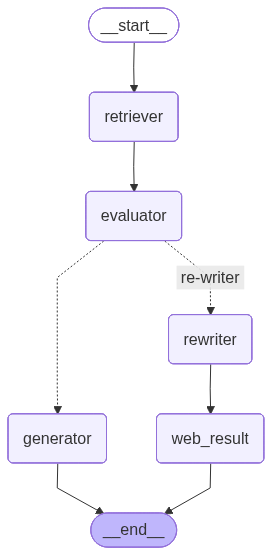

In [52]:
graph=StateGraph(State)
graph.add_node("retriever",retriever)
graph.add_node("evaluator",evaluator)
graph.add_node("rewriter",rewriter)
graph.add_node("generator",generator)
graph.add_node("web_result",web_result)

graph.set_entry_point("retriever")

graph.add_edge("retriever","evaluator")
graph.add_conditional_edges("evaluator",router,{"generator":"generator","re-writer":"rewriter"})
graph.add_edge("generator",END)
graph.add_edge("rewriter","web_result")
graph.add_edge("web_result",END)


graph_builder=graph.compile()
graph_builder


In [53]:
graph_builder.invoke({"query":"What is Transformer"})

{'query': 'What is Transformer',
 'chunks': ['Transformer  \nelectrical transformer is a static electrical machine which transforms electrical power from one circuit to \nanother circuit, without changing the frequency. Transformer can increase or decrease the voltage with \ncorresponding decrease or increase in current. \nWorking principle of transformer \n \n The basic principle behind working of a transformer is the phenomenon of mutual induction between two \nwindings linked by common magnetic flux. The figure at right shows the simplest form of a transformer.',
  'Phasor Diagram of the Transformer on Capacitive Load',
  '(i) Core type transformer \nIn core type transformer, windings are cylindrical former wound, mounted on  the core limbs as shown in the \nfigure above. The cylindrical coils have different layers and each layer is insulated from each other. Materials \nlike paper, cloth or mica can be used for insulation. Low voltage windings are placed nearer to the core, as they

In [ ]:
result=graph_builder.invoke({"query":"What is main components of a Transformers"})
print(result["answer"])

Based on the context provided, the main components of a transformer are:

1. Primary winding
2. Secondary winding
3. Core (which provides a magnetic path for the flux)

These components are electrically separated but magnetically linked to each other.
